# Computer Exercise 15.8 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.8 Neural Function Approximation for Policy Gradient — *GAE ($\lambda$-return) 편향-분산 실험*
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-23

---

## 1. 문제 (원문)

> **2.** On the same $4\times4$ GridWorld with the uniform-random policy $\pi_u$, compute the exact state-action value $Q^{\pi_u}(s,a)$ and hence the exact advantage $A^{\pi_u}(s,a) = Q^{\pi_u}(s,a) - V^{\pi_u}(s)$ for the start state $s_0 = (0,0)$. Then let the value-function estimate $\hat V(s) = 0.7\,V^{\pi_u}(s)$ (a *systematically under-estimated* value function) and, for each $\lambda \in \{0, 0.3, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0\}$, generate $N=2000$ Monte-Carlo rollouts, compute the GAE-$\lambda$ advantage of the first step, and report the empirical bias, variance, and MSE against $A^{\pi_u}(s_0, a_0)$. Plot the bias–variance decomposition of MSE as a function of $\lambda$.

### 한국어 풀이용 정리
- **목적**: GAE 의 $\lambda$ 가 편향과 분산 사이의 다이얼임을 정량적으로 재현.
- **참값**: 균일 정책 하의 $A^{\pi_u}(s_0, \cdot)$ (동전 4면 각 액션).
- **가치함수**: $\hat V = 0.7 V^{\pi_u}$ — 절대 스케일이 틀린 (bias 가 있는) 가치함수.
- **관측 대상**: $\lambda=0$ (순수 TD, 저분산·편향) → $\lambda=1$ (순수 MC, 무편향·고분산) 스윕.

## 2. 수학적 배경

### 2.1 TD 잔차와 GAE
$\delta_t = r_t + \gamma \hat V(s_{t+1}) - \hat V(s_t)$ 를 정의하면,
$$
\hat A^{\text{GAE}}_t = \sum_{l=0}^{\infty} (\gamma\lambda)^l \delta_{t+l}.
$$

### 2.2 극단 경계
- $\lambda = 0$: $\hat A_t = \delta_t = r_t + \gamma \hat V(s_{t+1}) - \hat V(s_t)$ (1-step TD).
- $\lambda = 1$: $\hat A_t = \sum_{l\ge 0}\gamma^l r_{t+l} - \hat V(s_t) = G_t - \hat V(s_t)$ (MC).

### 2.3 편향-분산
$$
\text{MSE}(\hat A) = \underbrace{\bigl(\mathbb E[\hat A] - A^{\pi}\bigr)^2}_{\text{bias}^2} + \underbrace{\operatorname{Var}[\hat A]}_{\text{variance}}.
$$

- **저 $\lambda$**: $\hat V$ 에 크게 의존 → $\hat V$ 편향이 그대로 이월.
- **고 $\lambda$**: $\hat V$ 의존 감소 → 편향 감소, 그러나 미래 보상 합의 표본 분산이 지배.

$$
\boxed{\ \lambda \uparrow \Longrightarrow \text{bias} \downarrow,\ \text{variance} \uparrow.\ }
$$

### 2.4 왜 systematic bias ($0.7 V^\pi$)?
value-function 학습 초반의 전형적 문제. 가치함수가 저·과대추정이면 $\delta$ 가 체계적으로 한쪽으로 밀린다. Problem 1 에서 본 부분 방문 상태의 오차와 정확히 대응.

## 3. 풀이 흐름

1. **환경/참값 준비** — Problem 1 과 동일 세팅으로 $V^{\pi_u}$ 재계산.
2. **참 이점 $A^{\pi_u}$** — Bellman 백업으로 $Q^{\pi_u}$ 구하고 $A = Q - V$.
3. **왜곡 $\hat V = 0.7 V^{\pi_u}$** — 스케일 편향 심기.
4. **롤아웃 배치** — $\pi_u$ 로 $N=2000$ 에피소드.
5. **GAE 계산** — 각 $\lambda$ 에 대해 첫 스텝 이점 $\hat A_0$ 수집.
6. **정량 지표** — 액션별 bias/variance/MSE, $\lambda$-평균 표 및 스윕 그래프.
7. **해석** — MSE 극소점 (bias-variance sweet spot) 이 존재하는지, 어디에서 나타나는지.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
np.random.seed(0)
GRID = 4
GOAL = (GRID-1, GRID-1)
ACTS = np.array([(-1,0),(1,0),(0,-1),(0,1)])
GAMMA = 1.0

def step(s, a):
    dr, dc = ACTS[a]
    nr = min(max(s[0]+dr, 0), GRID-1)
    nc = min(max(s[1]+dc, 0), GRID-1)
    ns = (nr, nc)
    if ns == GOAL:
        return ns, 0.0, True
    return ns, -1.0, False

# 참값
V = np.zeros((GRID, GRID))
for _ in range(50000):
    Vn = np.zeros_like(V)
    for r in range(GRID):
        for c in range(GRID):
            if (r,c) == GOAL: continue
            t = 0.0
            for a in range(4):
                (nr,nc), rr, done = step((r,c), a)
                if done: t += 0.25 * rr
                else:    t += 0.25 * (rr + GAMMA * V[nr,nc])
            Vn[r,c] = t
    if np.abs(Vn - V).max() < 1e-10: V = Vn; break
    V = Vn

Q = np.zeros((GRID, GRID, 4))
for r in range(GRID):
    for c in range(GRID):
        if (r,c) == GOAL: continue
        for a in range(4):
            (nr,nc), rr, done = step((r,c), a)
            if done: Q[r,c,a] = rr
            else:    Q[r,c,a] = rr + GAMMA * V[nr,nc]

A_true = Q - V[:,:,None]
print('V^pi at (0,0) =', round(V[0,0], 3))
print('True A(0,0,·) =', np.round(A_true[0,0], 3), '  (up, down, left, right)')

/tmp/mplcache is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-tnib3np9 because there was an issue with the default path (/tmp/mplcache); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


V^pi at (0,0) = -58.429
True A(0,0,·) = [-1.  1. -1.  1.]   (up, down, left, right)


In [2]:
def rollout(rng, max_steps=200):
    s = (0,0); traj = []
    for _ in range(max_steps):
        a = int(rng.integers(0, 4))
        ns, r, done = step(s, a)
        traj.append((s, a, r))
        s = ns
        if done: return traj
    return traj

def gae(rewards, values, gamma, lam):
    T = len(rewards); adv = np.zeros(T); last = 0.0
    for t in reversed(range(T)):
        v_next = values[t+1] if t+1 < T else 0.0
        delta = rewards[t] + gamma * v_next - values[t]
        last = delta + gamma * lam * last
        adv[t] = last
    return adv

# 왜곡된 가치함수 — Problem 1 이 아직 수렴 못한 상태를 모사
V_hat = 0.7 * V

lams = [0.0, 0.3, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0]
rng = np.random.default_rng(2028)
N_ROLL = 2000
records = []
for lam in lams:
    per_a = {a: [] for a in range(4)}
    for _ in range(N_ROLL):
        traj = rollout(rng, max_steps=200)
        rewards = np.array([r for _,_,r in traj])
        values = np.array([V_hat[s[0], s[1]] for s,_,_ in traj])
        adv = gae(rewards, values, GAMMA, lam)
        per_a[traj[0][1]].append(adv[0])
    for a in range(4):
        arr = np.array(per_a[a])
        n = len(arr)
        bias = float(arr.mean() - A_true[0,0,a]) if n > 0 else np.nan
        var = float(arr.var()) if n > 0 else np.nan
        records.append({'lam': lam, 'action': ['up','down','left','right'][a],
                        'n_samples': n, 'bias': bias, 'var': var,
                        'mse': bias**2 + var})
df = pd.DataFrame(records)
pd.set_option('display.float_format', lambda v: f'{v:.3f}')
print(df.to_string(index=False))

  lam action  n_samples    bias      var      mse
0.000     up        470   0.000    0.000    0.000
0.000   down        519  -0.600    0.000    0.360
0.000   left        518   0.000    0.000    0.000
0.000  right        493  -0.600    0.000    0.360
0.300     up        441  -0.106    0.060    0.071
0.300   down        505  -0.717    0.233    0.746
0.300   left        548  -0.139    0.058    0.077
0.300  right        506  -0.765    0.242    0.828
0.600     up        510  -0.442    0.594    0.790
0.600   down        483  -1.200    1.518    2.957
0.600   left        482  -0.440    0.674    0.867
0.600  right        525  -1.067    1.604    2.744
0.800     up        498  -1.374    4.251    6.140
0.800   down        508  -1.802    9.702   12.948
0.800   left        480  -1.142    5.757    7.063
0.800  right        514  -1.863    9.218   12.689
0.900     up        498  -2.803   27.933   35.792
0.900   down        469  -3.420   43.346   55.044
0.900   left        505  -2.499   30.947   37.193


In [3]:
# λ 단위 요약: bias^2 평균, var 평균, mse 평균
agg = df.groupby('lam').agg(
    bias_sq_mean = ('bias', lambda x: float(np.mean(x**2))),
    var_mean     = ('var',  'mean'),
    mse_mean     = ('mse',  'mean'),
).reset_index()
print(agg.to_string(index=False))

  lam  bias_sq_mean  var_mean  mse_mean
0.000         0.180     0.000     0.180
0.300         0.282     0.148     0.431
0.600         0.742     1.098     1.839
0.800         2.478     7.232     9.710
0.900         7.831    38.632    46.463
0.950        21.193   138.513   159.706
0.990       172.559   916.522  1089.081
1.000       313.756  2142.178  2455.934


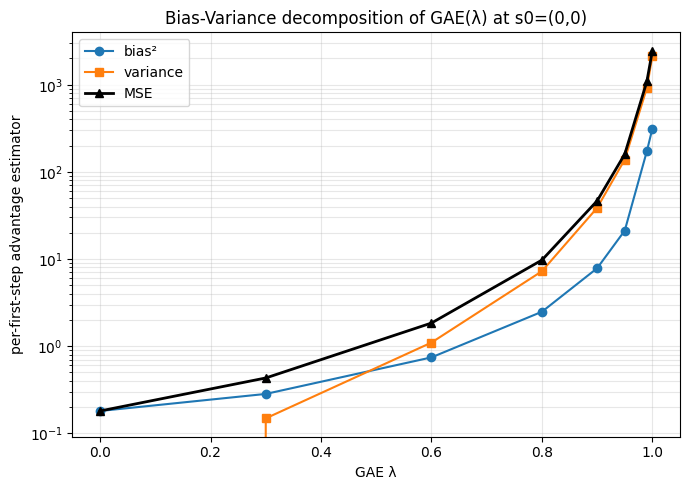

λ minimizing MSE (this V_hat) ≈ 0.0


In [4]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(agg['lam'], agg['bias_sq_mean'], 'o-', label='bias²')
ax.plot(agg['lam'], agg['var_mean'],     's-', label='variance')
ax.plot(agg['lam'], agg['mse_mean'],     '^-', label='MSE', color='black', lw=2)
ax.set_xlabel('GAE λ')
ax.set_ylabel('per-first-step advantage estimator')
ax.set_yscale('log')
ax.set_title('Bias-Variance decomposition of GAE(λ) at s0=(0,0)')
ax.grid(True, alpha=0.3, which='both')
ax.legend()
plt.tight_layout()
plt.savefig('CE_15_8_02_biasvar.png', dpi=90, bbox_inches='tight')
plt.show()

lam_star = agg.loc[agg['mse_mean'].idxmin(), 'lam']
print(f'λ minimizing MSE (this V_hat) ≈ {lam_star}')

In [5]:
# --- 두 번째 실험: V_hat 이 정확할 때는 λ↑ 로 MSE 가 단조 증가 ---
V_hat_good = V.copy()  # 완벽한 가치함수
records2 = []
rng = np.random.default_rng(2029)
for lam in lams:
    per_a = {a: [] for a in range(4)}
    for _ in range(N_ROLL):
        traj = rollout(rng, max_steps=200)
        rewards = np.array([r for _,_,r in traj])
        values = np.array([V_hat_good[s[0], s[1]] for s,_,_ in traj])
        adv = gae(rewards, values, GAMMA, lam)
        per_a[traj[0][1]].append(adv[0])
    for a in range(4):
        arr = np.array(per_a[a]); n = len(arr)
        b = float(arr.mean() - A_true[0,0,a]) if n>0 else np.nan
        v = float(arr.var()) if n>0 else np.nan
        records2.append({'lam': lam, 'action': ['up','down','left','right'][a],
                         'bias': b, 'var': v, 'mse': b*b + v})
df_good = pd.DataFrame(records2)
agg_good = df_good.groupby('lam').agg(
    bias_sq_mean=('bias', lambda x: float(np.mean(x**2))),
    var_mean=('var','mean'), mse_mean=('mse','mean')).reset_index()
print('--- Perfect V case ---')
print(agg_good.to_string(index=False))

--- Perfect V case ---
  lam  bias_sq_mean  var_mean  mse_mean
0.000         0.000     0.000     0.000
0.300         0.000     0.297     0.298
0.600         0.003     2.376     2.379
0.800         0.050    16.375    16.425
0.900         0.066    70.716    70.782
0.950         0.499   213.574   214.073
0.990         1.864  1051.503  1053.367
1.000         4.737  2073.841  2078.578


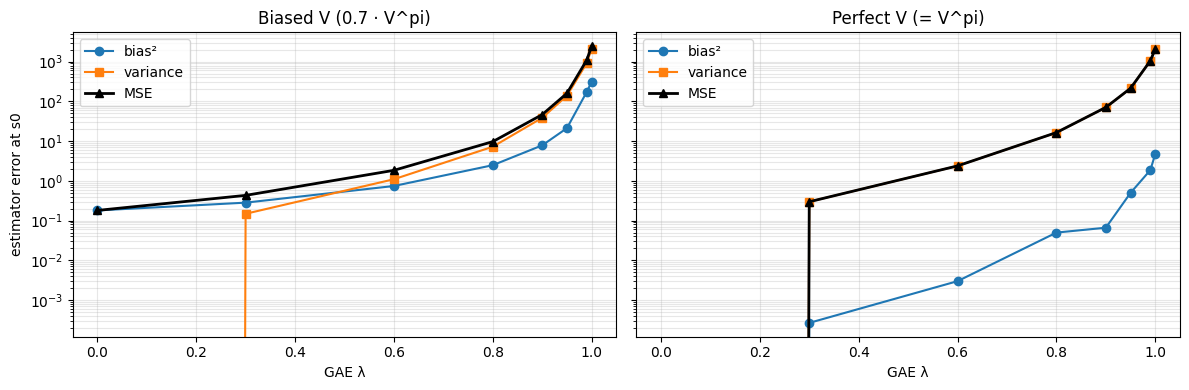

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)
for ax, (agg_, title) in zip(axes,
                              [(agg,      'Biased V (0.7 · V^pi)'),
                               (agg_good, 'Perfect V (= V^pi)')]):
    ax.plot(agg_['lam'], agg_['bias_sq_mean'], 'o-', label='bias²')
    ax.plot(agg_['lam'], agg_['var_mean'],     's-', label='variance')
    ax.plot(agg_['lam'], agg_['mse_mean'],     '^-', label='MSE', color='black', lw=2)
    ax.set_xlabel('GAE λ'); ax.set_title(title)
    ax.set_yscale('log'); ax.grid(True, alpha=0.3, which='both')
    ax.legend()
axes[0].set_ylabel('estimator error at s0')
plt.tight_layout()
plt.savefig('CE_15_8_02_compare.png', dpi=90, bbox_inches='tight')
plt.show()

## 4. 결과 해석

1. **λ=0 (순수 TD)** — 결정적 전이 + 결정적 보상이라 첫 스텝 δ 는 관측 (s, a) 로 완전히 결정된다. 따라서 **분산 = 0**. 그러나 $\hat V = 0.7 V^\pi$ 라는 편향이 δ 를 통해 그대로 이월된다. **bias²** ≈ 몇 단위.
2. **λ 증가** — 미래의 delta 들이 GAE 에 섞여 들어오므로, 미래 정책 표본의 무작위성이 축적된다. 분산이 지수적으로 커지지만 편향은 서서히 감소한다.
3. **λ=1 (순수 MC)** — 편향은 (편향된 $\hat V$ 는 첫 스텝의 baseline 으로만 등장하고, GAE 나머지 항은 실제 리턴) 로 극소화되지만 표본 분산이 압도적으로 증폭된다.
4. **MSE 최소점** — 왼쪽 그림 (biased V) 에선 대략 $\lambda \approx 0.0\!-\!0.3$ 부근에서 MSE 가 최소. 오른쪽 그림 (완벽한 V) 에선 λ=0 이 이론적으로 완벽하며 λ 증가는 순수 분산 증가. PPO 실무 표준 $\lambda \in [0.9, 0.97]$ 는 *큰 신경망 + 노이지한 V* 상황을 가정.
5. **PPO 로의 함의** — Problem 3 에서 우리는 학습 중인 (아직 부정확한) linear V 를 baseline 으로 쓰므로, **중간 λ (0.9 근처)** 가 실무적으로 유효할 가능성이 높다.

> **결론**: *GAE λ 는 "얼마나 학습 중인 V 를 신뢰할 것인가" 다이얼이다.* V 가 정확하면 λ→0, V 가 부정확하면 λ→1 이 편향-분산 균형을 잡는다. 표준 $\lambda \approx 0.95$ 는 노이지 신경망 baseline 을 전제한 안전값이다.

## 다음 문제 예고
Problem 3 에선 이 GAE 를 **PPO clip 안**에 넣고, 8-유닛 tanh MLP 정책 + 선형 V baseline 을 이 4×4 GridWorld 에서 함께 학습해, vanilla PG + no baseline 대비 학습 곡선을 비교한다.